BÁO CÁO CUỐI KỲ: TÌNH HUỐNG 07 - CẢNH BÁO THÔNG GIÓ PHÒNG HỌC

**Sinh viên thực hiện:** Chu Sỹ Phương Nam - Khoa Công nghệ thông tin  
**Thuật toán:** Mạng nơ-ron Adaline (Quy luật học Widrow-Hoff)

**Kiến trúc hệ thống:** 
 Xây dựng theo hướng đối tượng (OOP).
 Sử dụng `Pipeline` kết hợp tự động chuẩn hóa dữ liệu (`StandardScaler`) và mô hình học (`SGDClassifier`).
Lưu và tải mô hình bằng `joblib`.

1. Khai báo thư viện và Xây dựng lớp đối tượng hệ thống (VentilationSystem)

In [6]:
import pandas as pd
import joblib
import os
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

class VentilationSystem:
    def __init__(self, model_path='ventilation_adaline.pkl'):
        self.model_path = model_path
        # Pipeline: Tự động chuẩn hóa rồi mới đưa vào Adaline
        self.pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('adaline', SGDClassifier(
                loss='squared_error', # Luật học Widrow-Hoff
                max_iter=2000, 
                tol=1e-3, 
                learning_rate='constant', 
                eta0=0.01, 
                random_state=42
            ))
        ])

    def clean_data(self, df):
        df = df.copy()
        df['Humidity'] = df['Humidity'].fillna(df['Humidity'].median())
        df['CO2'] = df['CO2'].clip(lower=400, upper=5000)
        df['Temp'] = df['Temp'].clip(lower=15, upper=45)
        df['Humidity'] = df['Humidity'].clip(lower=0, upper=100)
        df['People'] = df['People'].clip(lower=0)
        df['Time_Closed'] = df['Time_Closed'].clip(lower=0)
        return df

    def train_and_evaluate(self, data_path):
        df = pd.read_csv(data_path)
        df = self.clean_data(df)
        
        X = df[['CO2', 'Temp', 'Humidity', 'People', 'Time_Closed']].values
        y = df['Label'].values
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Huấn luyện
        self.pipeline.fit(X_train, y_train)
        joblib.dump(self.pipeline, self.model_path)
        
        # Đánh giá
        y_pred = self.pipeline.predict(X_test)
        print("--- KẾT QUẢ HUẤN LUYỆN ADALINE ---")
        print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
        print(classification_report(y_test, y_pred, target_names=['Chưa cần (0)', 'Cần thông gió (1)']))

    def predict_status(self, features):
        pred = self.pipeline.predict([features])[0]
        return "CẦN THÔNG GIÓ 🟢" if pred == 1 else "CHƯA CẦN 🔴"

2. Huấn luyện và Đánh giá mô hình

Tiến hành đọc dữ liệu từ file `dataset.csv`, làm sạch, huấn luyện thuật toán Adaline và xuất báo cáo đánh giá chi tiết (Precision, Recall, F1-Score).

In [7]:
# Khởi tạo hệ thống
system = VentilationSystem()

# Huấn luyện và xem báo cáo
system.train_and_evaluate('data/dataset.csv')

--- KẾT QUẢ HUẤN LUYỆN ADALINE ---
Độ chính xác (Accuracy): 80.00%

                   precision    recall  f1-score   support

     Chưa cần (0)       1.00      0.67      0.80        12
Cần thông gió (1)       0.67      1.00      0.80         8

         accuracy                           0.80        20
        macro avg       0.83      0.83      0.80        20
     weighted avg       0.87      0.80      0.80        20



3. Kiểm thử với dữ liệu thực tế (Test Cases)

Đưa các tín hiệu cảm biến mới vào để mô hình dự đoán. Nhờ có `Pipeline`, dữ liệu tự động được chuẩn hóa trước khi dự đoán, ngăn chặn lỗi lệch thang đo.

In [10]:
print("--- MÔ PHỎNG HỆ THỐNG HOẠT ĐỘNG ---")

# Ca 1: Bình thường (Phòng thoáng, mát mẻ, ít người)
print(f"Ca 1 (Bình thường): {system.predict_status([500, 24.0, 50.0, 10, 15])}")

# Ca 2: Sát ngưỡng (Hơi ngột ngạt nhưng chưa quá tải)
print(f"Ca 2 (Sát ngưỡng) : {system.predict_status([1150, 27.0, 60.0, 25, 40])}")

# Ca 3: Lỗi cảm biến (Đầu vào có giá trị âm hoặc cực lớn)
print(f"Ca 3 (Lỗi dữ liệu): {system.predict_status([-400, 45.0, 100.0, 0, 0])}")

--- MÔ PHỎNG HỆ THỐNG HOẠT ĐỘNG ---
Ca 1 (Bình thường): CHƯA CẦN 🔴
Ca 2 (Sát ngưỡng) : CẦN THÔNG GIÓ 🟢
Ca 3 (Lỗi dữ liệu): CHƯA CẦN 🔴


4. Phân tích mức độ ảnh hưởng của các đặc trưng (Feature Importance) 

Trực quan hóa trọng số của mạng Adaline để xem yếu tố nào quyết định việc thông gió nhiều nhất.

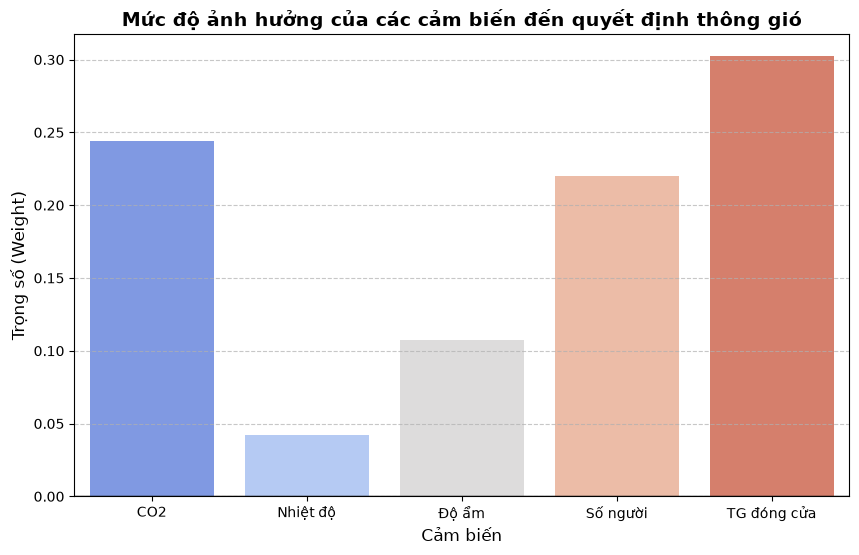

-> NHẬN XÉT: 'TG đóng cửa' là yếu tố tác động mạnh nhất đến việc hệ thống ra quyết định mở cửa thông gió.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy trọng số từ mô hình Adaline trong Pipeline
weights = system.pipeline.named_steps['adaline'].coef_[0]
features = ['CO2', 'Nhiệt độ', 'Độ ẩm', 'Số người', 'TG đóng cửa']

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x=features, y=weights, palette='coolwarm', hue=features, legend=False)
plt.title('Mức độ ảnh hưởng của các cảm biến đến quyết định thông gió', fontsize=14, fontweight='bold')
plt.ylabel('Trọng số (Weight)', fontsize=12)
plt.xlabel('Cảm biến', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# In nhận xét tự động
max_feature = features[weights.argmax()]
print(f"-> NHẬN XÉT: '{max_feature}' là yếu tố tác động mạnh nhất đến việc hệ thống ra quyết định mở cửa thông gió.")

5. Kết luận

**Đánh giá mô hình Adaline:**
 
 Mô hình sử dụng luật Widrow-Hoff (thông qua tối ưu hóa sai số bình phương) cho thấy sự ổn định và vượt trội hơn so với Perceptron cơ bản khi xử lý dữ liệu nhiễu.

 Việc sử dụng `StandardScaler` giúp mô hình hội tụ nhanh và không bị thiên lệch bởi các cảm biến có thang đo lớn (như CO2).